In [1]:
import pandas as pd
import json

In [2]:
# Load the batch response JSONL file and extract custom_id and response message content
batch_answerable = []
with open('batch/batch_68c2e547b8ec8190b9160922db55bb45_output.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        batch_answerable.append({
            'id': data.get('custom_id'),
            'llm_answerable': data.get('response').get('body').get('choices')[0].get('message').get('content')
        })

df_answerable = pd.DataFrame(batch_answerable)
df_answerable['llm_answerable'].unique()

array(['False', 'True'], dtype=object)

In [3]:
df_answerable['llm_answerable'] = df_answerable['llm_answerable'].str.replace(r".*true.*", "True", case=False, regex=True)
df_answerable['llm_answerable'] = df_answerable['llm_answerable'].str.replace(r".*false.*", "False", case=False, regex=True)

df_answerable['llm_answerable'].unique()

array(['False', 'True'], dtype=object)

In [4]:
batch_sound = []
with open('batch/batch_68c2e547b8ec8190b9160922db55bb45_output.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        batch_sound.append({
            'id': data.get('custom_id'),
            'llm_sound': data.get('response').get('body').get('choices')[0].get('message').get('content')
        })

df_sound = pd.DataFrame(batch_sound)
df_sound['llm_sound'].unique()

array(['False', 'True'], dtype=object)

In [5]:
df_sound['llm_sound'] = df_sound['llm_sound'].str.replace(r".*true.*", "True", case=False, regex=True)
df_sound['llm_sound'] = df_sound['llm_sound'].str.replace(r".*false.*", "False", case=False, regex=True)

df_sound['llm_sound'].unique()

array(['False', 'True'], dtype=object)

In [6]:
batch_df = df_sound.merge(df_answerable, on='id', how='outer')
batch_df.to_csv('batch/questions_llm_labelled.csv', index=False)

batch_df.head()

,id,llm_sound,llm_answerable
0,0203b828-6d87-4401-a595-2641e724a84a,False,False
1,023d8cff-cf4b-4485-82d6-0e3383c0a232,True,True
2,03fc9796-972f-4ae6-8ebd-f86fcd7fed1f,False,False
3,045f9534-2b60-4d2a-8eab-679494476682,False,False
4,04f63c22-157d-4d25-bdae-2ffc1b0b57c2,False,False


In [7]:
manual_df = pd.read_csv('batch/questions_manually_labelled.csv')
manual_df.head()

,id,question,manual_label
0,9402476c-5eab-4307-b55e-2110c833978f,The following are used for treatment of postop...,False
1,a3ce0f33-c761-411d-b548-f889e3b9c30e,A 43-year-old woman develops acute renal failu...,False
2,b347d2bf-902d-4c22-beb3-68ce096f90b5,On doing laparoscopic cholecystectomy patient ...,False
3,ed133ef1-28de-4c9d-b539-98d02e14161e,A 73-year-old woman with a long history of hea...,False
4,8656397f-6dcc-4c6b-abbb-b6bc4c442388,The following are used for treatment of postop...,False


In [8]:
df = manual_df.merge(batch_df, on='id', how='outer')
# df['llm_label'] = (df['llm_answerable'] == 'True') & (df['llm_sound'] == 'True')
df['llm_label'] = df['llm_answerable']

df.head()

,id,question,manual_label,llm_sound,llm_answerable,llm_label
0,0203b828-6d87-4401-a595-2641e724a84a,When bleeding doesn't stop on applying pressur...,True,False,False,False
1,023d8cff-cf4b-4485-82d6-0e3383c0a232,A 65-year old man presented with skin lesions ...,True,True,True,True
2,03fc9796-972f-4ae6-8ebd-f86fcd7fed1f,Which of the following human malignancy is hig...,False,False,False,False
3,045f9534-2b60-4d2a-8eab-679494476682,A 65-year-old man with a long history of diabe...,True,False,False,False
4,04f63c22-157d-4d25-bdae-2ffc1b0b57c2,Cat bites in child treatment - false is,False,False,False,False


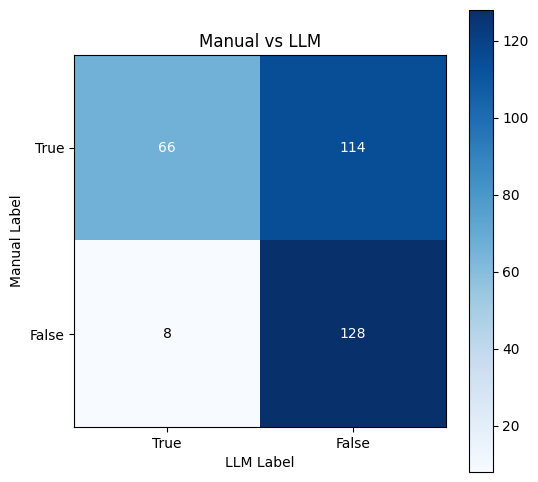

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ensure both columns are boolean or string 'True'/'False'
df['manual_label'] = df['manual_label'].astype(str)
df['llm_label'] = df['llm_label'].astype(str)

labels = ['True', 'False']
cm = confusion_matrix(df['manual_label'], df['llm_label'], labels=labels)

plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Manual vs LLM')
plt.xlabel('LLM Label')
plt.ylabel('Manual Label')
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.colorbar()

# Annotate each cell with the numeric value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.show()


In [10]:
df[(df['manual_label'] == 'False') & (df['llm_label'] == 'True')].to_csv('batch/question_fp.csv', index=False)
df[(df['manual_label'] == 'True') & (df['llm_label'] == 'False')].to_csv('batch/question_fn.csv', index=False)